# I will show what it actually looks like to train a neural network from scratch

> We will use PyTorch to have access to its autodiff

In [35]:
import torch
import torch.nn.functional as F
import numpy as np

## Let's make a basic neural network which predicts salary based on a few features

In [7]:
import pandas as pd

columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

df = pd.read_csv(
    "adult/adult.csv",
    header=None,
    names=columns,
    skipinitialspace=True
)

print(df.head())

   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital_gain  capital_loss  hours_per_week native_country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

In [ ]:
df = pd.get_dummies(df)

df["income"] = (df["income_>50K"] == 1).astype(int)

X = df.drop(columns=["income_<=50K", "income_>50K", "income"])
y = df["income_>50K"]


In [19]:
X

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native_country_Portugal,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia
0,39,77516,13,2174,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,83311,13,0,0,13,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,38,215646,9,0,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,53,234721,7,0,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,28,338409,13,0,0,40,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,257302,12,0,0,38,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
32557,40,154374,9,0,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
32558,58,151910,9,0,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
32559,22,201490,9,0,0,20,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [15]:
y

0        False
1        False
2        False
3        False
4        False
         ...  
32556    False
32557     True
32558    False
32559    False
32560     True
Name: income_>50K, Length: 32561, dtype: bool

In [24]:
X = X.astype(float)
y = y.astype(float)
X_tensor = torch.tensor(X.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32)

In [26]:
X_tensor

tensor([[3.9000e+01, 7.7516e+04, 1.3000e+01,  ..., 1.0000e+00, 0.0000e+00,
         0.0000e+00],
        [5.0000e+01, 8.3311e+04, 1.3000e+01,  ..., 1.0000e+00, 0.0000e+00,
         0.0000e+00],
        [3.8000e+01, 2.1565e+05, 9.0000e+00,  ..., 1.0000e+00, 0.0000e+00,
         0.0000e+00],
        ...,
        [5.8000e+01, 1.5191e+05, 9.0000e+00,  ..., 1.0000e+00, 0.0000e+00,
         0.0000e+00],
        [2.2000e+01, 2.0149e+05, 9.0000e+00,  ..., 1.0000e+00, 0.0000e+00,
         0.0000e+00],
        [5.2000e+01, 2.8793e+05, 9.0000e+00,  ..., 1.0000e+00, 0.0000e+00,
         0.0000e+00]])

In [27]:
y_tensor

tensor([0., 0., 0.,  ..., 0., 0., 1.])

In [29]:
print(X_tensor.shape)
print(y_tensor.shape)

torch.Size([32561, 108])
torch.Size([32561])


In [54]:
in_dim = 108 # num_features
out_dim = 2 # >= 50k or < 50k
hidden_dim = 256

w1 = torch.randn(in_dim, hidden_dim).requires_grad_()
w2 = torch.randn(hidden_dim, hidden_dim).requires_grad_()
w3 = torch.randn(hidden_dim, out_dim).requires_grad_()

In [78]:
def forward(x):
  x = w1.T @ x
  x = torch.sigmoid(x)
  x = w2.T @ x
  x = torch.sigmoid(x)
  logit = w3.T @ x
  return torch.softmax(logit, dim=0)

## Without training, these labels make no sense from the true label

In [55]:
print(f"Prediction: {forward(X_tensor[0])}")

y = torch.tensor(y, dtype=torch.long)
y_onehot = F.one_hot(y, num_classes=2)

print(y_onehot[0])

Prediction: tensor([  1.8815, -23.4414], grad_fn=<MvBackward0>)
tensor([1, 0])


/var/folders/dv/3rt9dzq92qq4mwb8qz5mh_cw0000gn/T/ipykernel_7334/3481809575.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y, dtype=torch.long)


In [75]:
parameters = [w1, w2, w3]

In [76]:
for p in parameters:
    print(p.is_leaf, p.requires_grad)

True True
True True
True True


In [81]:
loss = []
lr = 1e-3
num_examples = 32561
epochs = 1
for epoch in range(epochs):
  for i in range(num_examples):
    for parameter in parameters:
      if parameter.grad is not None:
        parameter.grad.zero_()
    y_pred = forward(X_tensor[i])
    target = y_onehot[i]
    cur_loss = -(target * torch.log(y_pred + 1e-8)).sum()
    cur_loss.backward()

    print(cur_loss)

    loss += [cur_loss.item()]

    with torch.no_grad():
      for parameter in parameters:
        parameter -= lr * parameter.grad

tensor(-0., grad_fn=<NegBackward0>)
tensor(-0., grad_fn=<NegBackward0>)
tensor(-0., grad_fn=<NegBackward0>)
tensor(-0., grad_fn=<NegBackward0>)
tensor(-0., grad_fn=<NegBackward0>)
tensor(-0., grad_fn=<NegBackward0>)
tensor(-0., grad_fn=<NegBackward0>)
tensor(18.4207, grad_fn=<NegBackward0>)
tensor(18.4207, grad_fn=<NegBackward0>)
tensor(18.4207, grad_fn=<NegBackward0>)
tensor(18.4207, grad_fn=<NegBackward0>)
tensor(18.4207, grad_fn=<NegBackward0>)
tensor(-0., grad_fn=<NegBackward0>)
tensor(-0., grad_fn=<NegBackward0>)
tensor(18.4207, grad_fn=<NegBackward0>)
tensor(-0., grad_fn=<NegBackward0>)
tensor(-0., grad_fn=<NegBackward0>)
tensor(-0., grad_fn=<NegBackward0>)
tensor(-0., grad_fn=<NegBackward0>)
tensor(18.4207, grad_fn=<NegBackward0>)
tensor(18.4207, grad_fn=<NegBackward0>)
tensor(-0., grad_fn=<NegBackward0>)
tensor(-0., grad_fn=<NegBackward0>)
tensor(-0., grad_fn=<NegBackward0>)
tensor(-0., grad_fn=<NegBackward0>)
tensor(18.4207, grad_fn=<NegBackward0>)
tensor(-0., grad_fn=<NegBack

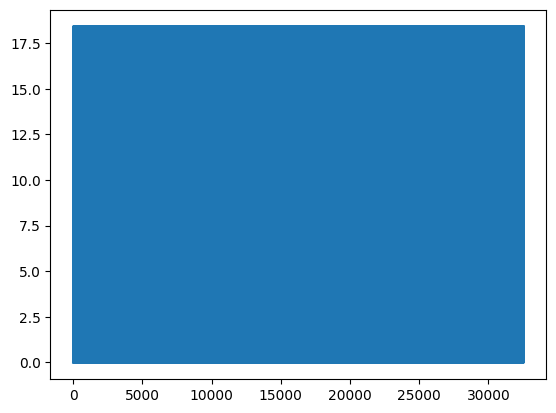

In [82]:
import matplotlib.pyplot as plt
plt.plot(loss)
plt.show()